# Track following

Step 7.5. The Phase 7 baseline: the car laps the racing line of `docs/track.md` on the room
map, localized by AMCL on top of the robot_localization EKF (`docs/localization.md`), with
Pure Pursuit. Slicks on tiles, 2026-09-27.

| run | speed | where it runs |
|---|---|---|
| pp_run1 | 60% of the profile, 0.46-0.60 m/s | AMCL and controller on the desktop, over wifi |
| pp_run3 | full profile, 0.77-1.0 m/s | everything on the Pi |
| pp_video | full profile | everything on the Pi (the bag caught /drive 1.1 s late) |

In [1]:
import sys
sys.path.append('../scripts')
sys.path.append('../ros2_ws/src/ackermann_control')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from PIL import Image
import bagtools as bt
from ackermann_control.pure_pursuit import lateral_error, load_track, nearest, steering
from vehicle_model import CMD, DEL, IZ, L, LR, M, TAU, forces

plt.rcParams['figure.dpi'] = 72
track = load_track('../ros2_ws/src/ackermann_bringup/maps/room_track.csv')
room = yaml.safe_load(open('../ros2_ws/src/ackermann_bringup/maps/room.yaml'))
room_img = np.array(Image.open('../ros2_ws/src/ackermann_bringup/maps/room.pgm'))

/home/pietro/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Controller and lookahead

Pure Pursuit about the rear axle (`ackermann_control/pure_pursuit.py`): the target is the
track point `lookahead` metres further along, the arc through it has curvature $2y/d^2$ with
the point at $(x, y)$ in the car frame, $\delta = \arctan(L\kappa)$, and the servo command comes
from the inverse of the measured steering map. Speed from the track profile. The node stops
on a pose older than 0.2 s, 0.5 m off the track, or after the laps asked for.

Lookahead $= L_0 + t_L v$. Chosen on the car of Phase 5 (`vehicle_model.py`: tires, spool,
0.17 s steering lag) plus the wheel speed loop, controlled at 50 Hz with the pose delayed and
noisy (2 cm, 0.5 deg), 3 laps at full speed.

In [2]:
TAU_U = 0.03    # s, wheel speed loop at 0.5 m/s (actuator_id.ipynb)


def deriv(x, d_cmd, u_cmd):
    # map position of the CG, heading, the Phase 5 states, wheel speed
    X, Y, psi, vx, vy, r, d, u = x
    fx, fy, mz = forces((vx, vy, r, d), u)
    return np.array([vx * np.cos(psi) - vy * np.sin(psi), vx * np.sin(psi) + vy * np.cos(psi), r,
                     fx / M + vy * r, fy / M - vx * r, mz / IZ, (d_cmd - d) / TAU, (u_cmd - u) / TAU_U])


def simulate(l0, tl, delay, laps=3, noise=0.02, dt=0.02, h=0.002, seed=0):
    rng = np.random.default_rng(seed)
    psi = track['yaw'][0]
    x = np.array([track['x'][0] + LR * np.cos(psi), track['y'][0] + LR * np.sin(psi), psi, 0.2, 0, 0, 0, 0.2])
    poses, errors, i = [], [], None
    for _ in range(int(laps * np.sum(0.05 / track['v']) / dt)):
        xr, yr = x[0] - LR * np.cos(x[2]), x[1] - LR * np.sin(x[2])     # rear axle
        poses.append((xr + noise * rng.normal(), yr + noise * rng.normal(), x[2] + np.radians(0.5) * rng.normal()))
        xm, ym, pm = poses[max(0, len(poses) - 1 - round(delay / dt))]
        i = nearest(track, xm, ym, i)
        errors.append(lateral_error(track, nearest(track, xr, yr, i), xr, yr))
        v = track['v'][i]
        delta = steering(track, i, xm, ym, pm, l0 + tl * v, L)
        d_cmd = np.interp(np.interp(delta, DEL, CMD), CMD, DEL)     # what the servo can reach
        for _ in range(round(dt / h)):
            k1 = deriv(x, d_cmd, v)
            k2 = deriv(x + h / 2 * k1, d_cmd, v)
            k3 = deriv(x + h / 2 * k2, d_cmd, v)
            k4 = deriv(x + h * k3, d_cmd, v)
            x = x + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
    e = np.array(errors[round(1 / dt):]) * 100
    return np.sqrt(np.mean(e ** 2)), np.abs(e).max()


rows = []
for l0, tl in [(0.2, 0.2), (0.3, 0.2), (0.3, 0.4), (0.4, 0.4)]:
    for delay in [0.1, 0.2]:
        rms, mx = simulate(l0, tl, delay)
        rows.append({'lookahead': f'{l0} + {tl} v', 'pose delay [s]': delay, 'error rms [cm]': rms, 'error max [cm]': mx})
pd.DataFrame(rows).round(1)

,lookahead,pose delay [s],error rms [cm],error max [cm]
0,0.2 + 0.2 v,0.1,10.4,22.0
1,0.2 + 0.2 v,0.2,20.4,41.8
2,0.3 + 0.2 v,0.1,4.0,7.6
3,0.3 + 0.2 v,0.2,12.5,27.5
4,0.3 + 0.4 v,0.1,3.7,7.4
5,0.3 + 0.4 v,0.2,7.6,13.0
6,0.4 + 0.4 v,0.1,4.3,9.4
7,0.4 + 0.4 v,0.2,6.8,13.1


A short lookahead follows the corners best without delay, and oscillates with it: 0.2 + 0.2 v
goes to 10-20 cm rms. **0.3 + 0.4 v** stays at 4-8 cm with up to 0.2 s of delay: the node's
default.

## Runs

The rear axle in the map at 50 Hz, as the controller sees it: the last AMCL correction
applied to the EKF pose. Lateral error to the nearest track point, from 1 s after the start.

In [3]:
runs, rows = {}, []
for name in ['pp_run1', 'pp_run3', 'pp_video']:
    d = bt.load(f'../data/{name}_parquet')
    t, X, Y = bt.map_pose(d)
    js = d['joint_states']
    moving = js['t'][js[['wl', 'wr']].abs().max(axis=1) > 1.0]
    w = (t > moving.iloc[0] + 1.0) & (t < moving.iloc[-1])
    t, X, Y = t[w], X[w], Y[w]
    idx, e, i = [], [], None
    for x, y in zip(X, Y):
        i = nearest(track, x, y, i)
        idx.append(i)
        e.append(lateral_error(track, i, x, y))
    idx, e = np.array(idx), np.array(e) * 100
    # a lap: the nearest track point wraps from the last quarter to the first
    n = len(track)
    crossings = t[1:][(idx[:-1] > 3 * n // 4) & (idx[1:] < n // 4)]
    runs[name] = (t - t[0], X, Y, e)
    rows.append({'run': name, 'speed': d['drive']['cmd_speed'].max(), 'driven [s]': t[-1] - t[0],
                 'lap times [s]': ', '.join(f'{x:.1f}' for x in np.diff(crossings)),
                 'error rms [cm]': np.sqrt(np.mean(e ** 2)), 'error 95% [cm]': np.percentile(np.abs(e), 95),
                 'error max [cm]': np.abs(e).max(), 'mean [cm]': e.mean()})
pd.DataFrame(rows).round(2)

,run,speed,driven [s],lap times [s],error rms [cm],error 95% [cm],error max [cm],mean [cm]
0,pp_run1,0.6,50.28,"17.1, 17.2",1.78,3.66,5.11,-0.36
1,pp_run3,1.0,29.90,"10.2, 10.1",2.70,5.08,6.30,-0.32
2,pp_video,1.0,29.90,"10.1, 10.2",2.59,4.92,6.83,-0.22


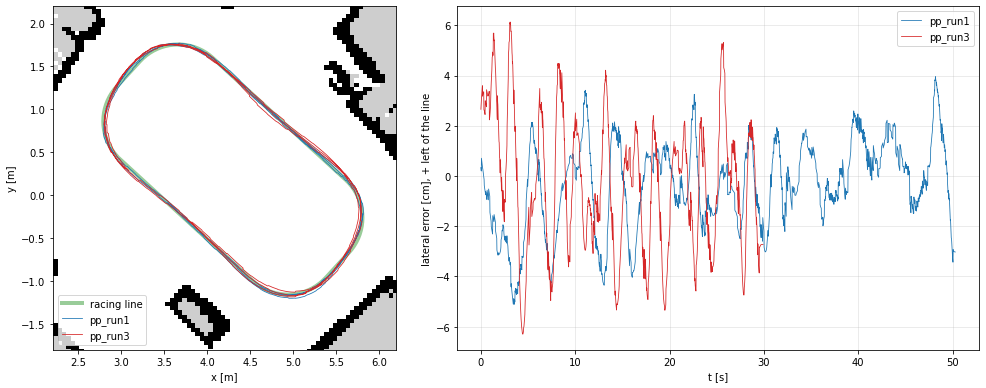

In [4]:
res, (x0, y0) = room['resolution'], room['origin'][:2]
h, w = room_img.shape
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={'width_ratios': [1, 1.4]})
ax[0].imshow(room_img, cmap='gray', extent=[x0, x0 + w * res, y0, y0 + h * res])
ax[0].plot(track['x'], track['y'], 'g', lw=4, alpha=0.4, label='racing line')
for name, c in [('pp_run1', 'C0'), ('pp_run3', 'C3')]:
    ax[0].plot(runs[name][1], runs[name][2], c, lw=0.8, label=name)
ax[0].set_xlim(2.2, 6.2)
ax[0].set_ylim(-1.8, 2.2)
ax[0].set_xlabel('x [m]')
ax[0].set_ylabel('y [m]')
ax[0].legend(loc='lower left')
for name, c in [('pp_run1', 'C0'), ('pp_run3', 'C3')]:
    ax[1].plot(runs[name][0], runs[name][3], c, lw=0.8, label=name)
ax[1].set_xlabel('t [s]')
ax[1].set_ylabel('lateral error [cm], + left of the line')
ax[1].grid(alpha=0.3)
ax[1].legend()
plt.tight_layout()
plt.show()

## Result

The car laps the racing line within 2-3 cm rms of it, 5-7 cm at worst, at 0.6 and at the
full profile (1.0 m/s on the straights, 0.77 in the corners at 1.0 m/s², ~40% of the rear
grip). Lap times match the profile: 10.1 s. The error peaks at the corner entries, where
Pure Pursuit cuts in and the 0.17 s steering lag shows, as the simulation predicts.

Measured against the localization, which itself moves by ~1-4 cm per AMCL update: at this
level the controller and the pose it gets are about as good as each other. That also means
this metric cannot see a localization error: pp_run1 started from a mark placed by eye, AMCL
was ~30 cm off and took ~4 s of driving to correct it. The other two started on the tape mark.

After the last lap the node commands zero at the start line; the car stops 10-15 cm past it.
Getting all of it onto the Pi took three fixes, in `docs/localization.md`: the wifi was
saturated by the data the desktop pulled, Fast DDS shared memory blocked on the ports of dead
nodes, and an /arm sent before discovery was lost.